In [1]:
import os
import random
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

## Datasetladen
In deze stap wordt de dataset met korte spraakcommando’s ingeladen en georganiseerd.  
Elk submapje in de dataset vertegenwoordigt één commando, bijvoorbeeld *up*, *down* of *right*.  
Door het gebruiken van `os.listdir()` worden de beschikbare categorieën automatisch uitgelezen en opgeslagen in de variabele `commands`.  
Zo ontstaat een gestructureerde basis waarop verdere data-extractie en verwerking kan plaatsvinden.


In [2]:
data_dir = "mini_speech_commands"  # map met submappen: up/, down/, left/, right/

commands = os.listdir(data_dir)
print("Commands:", commands)

Commands: ['down', 'go', 'left', 'no', 'right', 'stop', 'up', 'yes']


## Feature-extractie
Om de ruwe audio bruikbaar te maken voor een neuraal netwerk wordt elk audiobestand omgezet naar een **log-mel spectrogram**.  
Deze representatie vertaalt het audiosignaal naar een tweedimensionale structuur waarin:
- de horizontale as de tijd weergeeft,  
- de verticale as de frequentie,  
- en de kleurintensiteit de energie per frequentieband.

Dit type representatie behoudt de volledige tijd-frequentiestructuur van het signaal en is daardoor zeer effectief voor deep learning-modellen zoals CNN’s.  
De berekening gebeurt met behulp van **Librosa**, waarbij 64 Mel-filters worden toegepast en het resultaat wordt gelogaritmeerd om de schaal van de menselijke waarneming te benaderen.


In [3]:
def extract_features(file_path, max_len=2.0):
    audio, sr = librosa.load(file_path, sr=22050)
    max_samples = int(max_len * sr)
    if len(audio) > max_samples:
        audio = audio[:max_samples]
    else:
        audio = np.pad(audio, (0, max_samples - len(audio)))

    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

    # Normaliseer tussen 0 en 1
    mel_spec_norm = (mel_spec_db + 80) / 80.0
    return mel_spec_norm

In [4]:
X = []
y = []

for label_idx, command in enumerate(commands):
    folder = os.path.join(data_dir, command)
    for file in os.listdir(folder):
        if file.endswith(".wav"):
            path = os.path.join(folder, file)
            features = extract_features(path)
            X.append(features)
            y.append(label_idx)

X = np.array(X)
y = np.array(y)

print("Data shape:", X.shape)

Data shape: (8000, 64, 87)


## Datasetverdeling
Om de generalisatie van het model te toetsen, wordt de dataset opgesplitst in een **trainingsset** en een **testset**.  
Het model leert patronen uit de trainingsdata en wordt vervolgens geëvalueerd op de testdata, die het nog niet eerder heeft gezien.  
Door het gebruik van `train_test_split()` met een vaste random seed wordt de verdeling reproduceerbaar gehouden.


In [5]:
# Voeg kanaaldimensie toe
X = X[..., np.newaxis]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_classes = len(commands)
y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)

## Modelarchitectuur
Het model bestaat uit meerdere convolutielagen die frequentie- en tijdspatronen uit het spectrogram leren herkennen.  
Elke convolutielaag detecteert lokale kenmerken, zoals klanken of overgangsfrequenties, waarna poolinglagen zorgen voor dimensiereductie en reken-efficiëntie.

Het netwerk eindigt met volledig verbonden lagen (Dense Layers) en een softmax-uitgang,  
die de kansverdeling over alle mogelijke spraakcommando’s berekent.  
Deze structuur is geïnspireerd op bewezen CNN-modellen uit recente spraakherkenningsonderzoeken.


In [6]:
model = Sequential([
    Input(shape=X_train.shape[1:]),
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

## Compilatie en training
De compilatiefase definieert de optimizer, het verliescriterium en de evaluatiemaatstaven.  
Hier wordt **Adam** gebruikt vanwege zijn stabiliteit en efficiëntie bij geluidsdata,  
en **categorical cross-entropy** voor meerklassige classificatie.  

Het model wordt getraind over meerdere epochs, waarbij de trainingsaccuratesse en validatie-accuratesse worden bijgehouden.  
Een afname van de validatie-loss duidt op succesvolle generalisatie naar niet eerder geziene data.


In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=16,
)

Epoch 1/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2852 - loss: 1.8010 - val_accuracy: 0.4931 - val_loss: 1.4310
Epoch 2/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4762 - loss: 1.3590 - val_accuracy: 0.6194 - val_loss: 1.1128
Epoch 3/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5486 - loss: 1.1715 - val_accuracy: 0.6837 - val_loss: 0.9457
Epoch 4/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6075 - loss: 1.0305 - val_accuracy: 0.6988 - val_loss: 0.8568
Epoch 5/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6380 - loss: 0.9445 - val_accuracy: 0.7400 - val_loss: 0.7877
Epoch 6/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6681 - loss: 0.8682 - val_accuracy: 0.7613 - val_loss: 0.7096
Epoch 7/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7025 - loss: 0.7886 - val_accuracy: 0.7812 - val_loss: 0.6577
Epoch 8/20
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7294 - loss: 0.7276 - val_accuracy: 0.

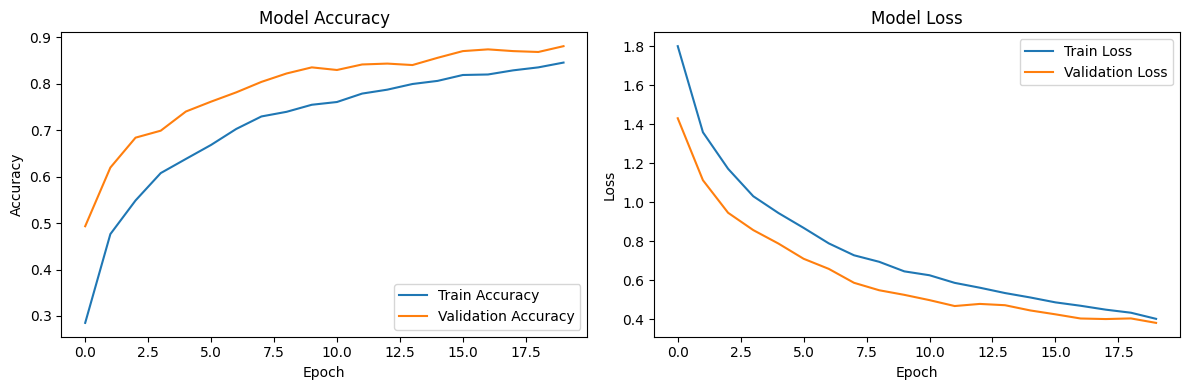

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy-plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# Loss-plot
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Validation Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.tight_layout()
plt.show()

## Confusion Matrix
In dit onderdeel wordt de prestaties van het model visueel geëvalueerd met behulp van een **confusion matrix**.  
Een confusion matrix laat zien hoeveel voorspellingen correct of fout waren per klasse (commando).

- De **rijen** vertegenwoordigen de **werkelijke labels** (de juiste commando’s).  
- De **kolommen** tonen de **voorspelde labels** door het model.  
- De waarden in de matrix geven aan hoe vaak een bepaald commando correct of fout werd geclassificeerd.

Hiermee kun je eenvoudig zien welke commando’s vaak met elkaar worden verward — bijvoorbeeld wanneer *“up”* regelmatig als *“go”* wordt herkend.  
Een lichte diagonalelijn (links-boven → rechts-onder) betekent dat de meeste voorspellingen juist zijn.  
De blauwe kleurintensiteit geeft de frequentie per klasseweer; hoe donkerder de kleur, hoe vaker een categorie correct werd herkend.

De matrix wordt berekend met:
- `confusion_matrix(y_true, y_pred)` uit **scikit-learn**,  
- en gevisualiseerd met `ConfusionMatrixDisplay()` en `matplotlib`.


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


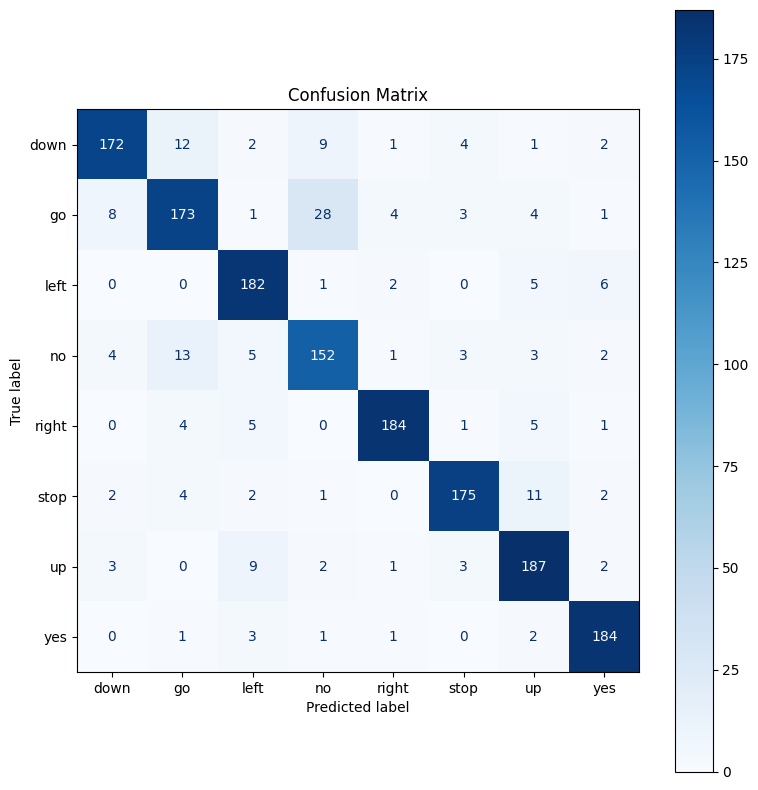

In [9]:

# Bereken voorspellingen en echte labels
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=commands)

plt.figure(figsize=(8, 8))
disp.plot(cmap="Blues", ax=plt.gca(), colorbar=True)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Testbestand: mini_speech_commands\down\ccf418a5_nohash_0.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


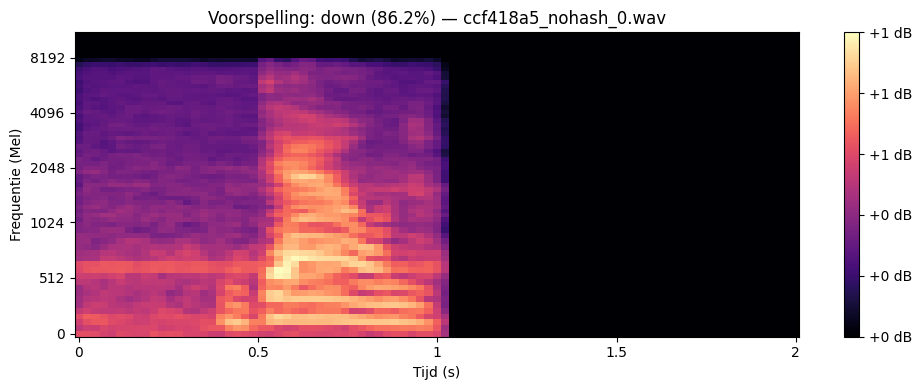

Testbestand: mini_speech_commands\go\c33682f0_nohash_0.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


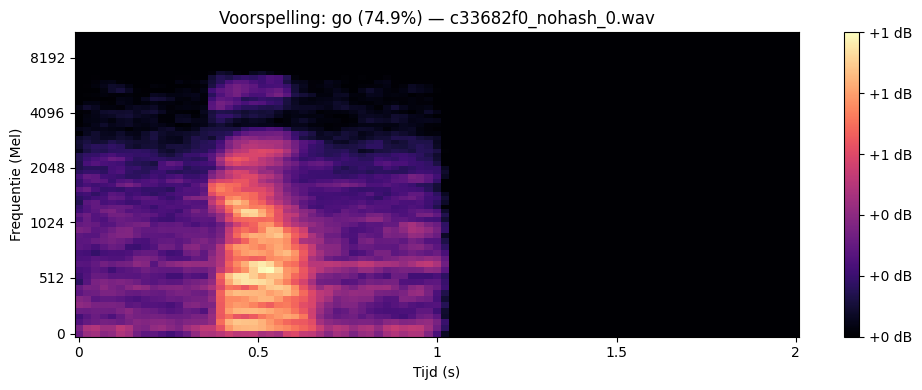

Testbestand: mini_speech_commands\left\5b09db89_nohash_3.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


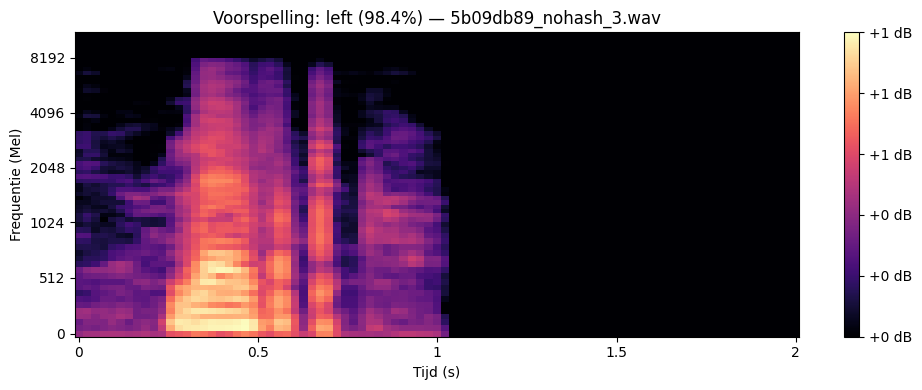

Testbestand: mini_speech_commands\no\afbec28d_nohash_1.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


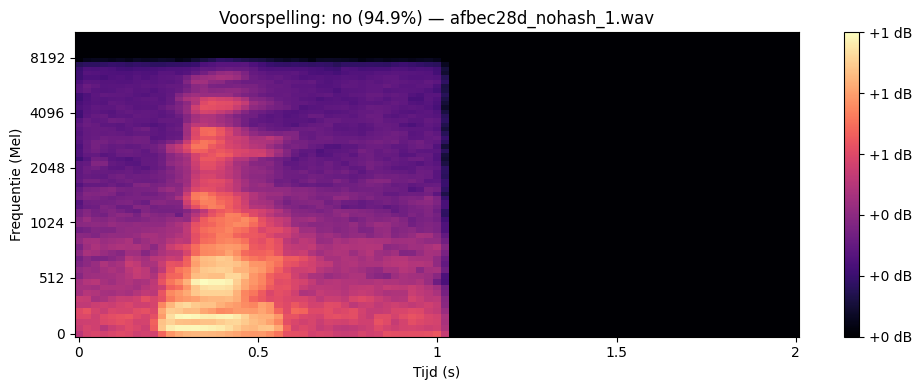

Testbestand: mini_speech_commands\right\742d6431_nohash_0.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


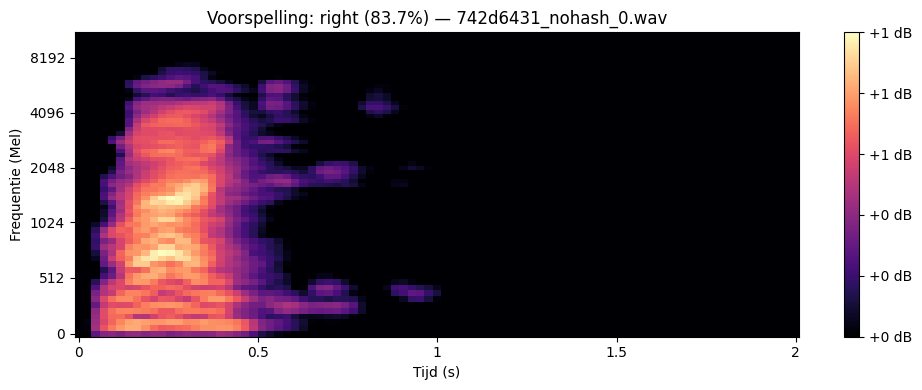

Testbestand: mini_speech_commands\stop\8dc26a15_nohash_1.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


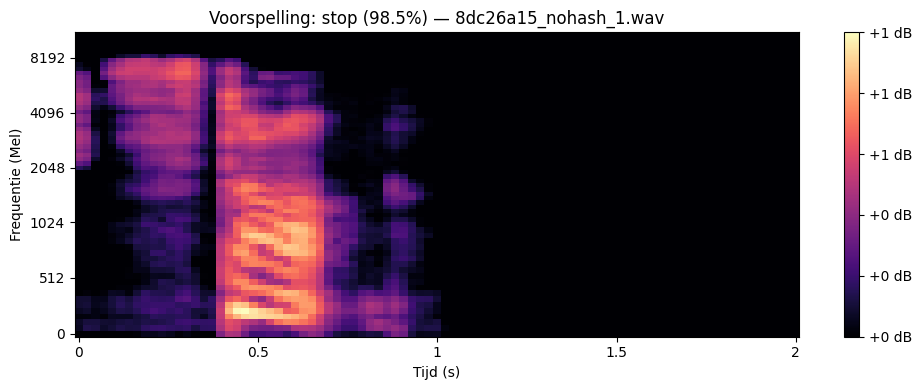

Testbestand: mini_speech_commands\up\712e4d58_nohash_2.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


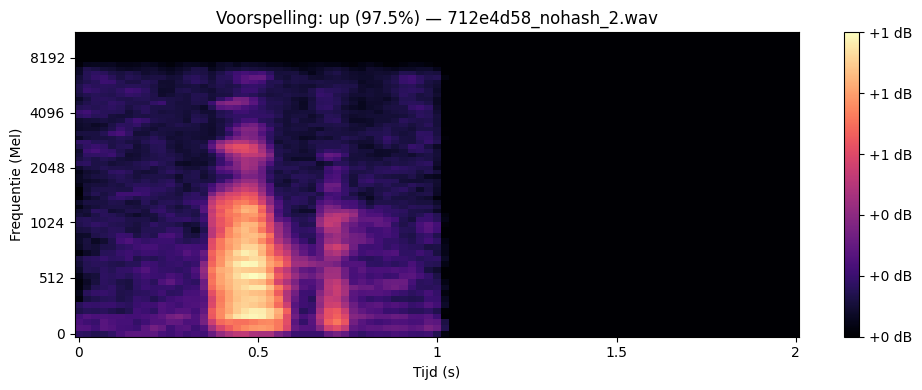

Testbestand: mini_speech_commands\yes\10ace7eb_nohash_2.wav
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


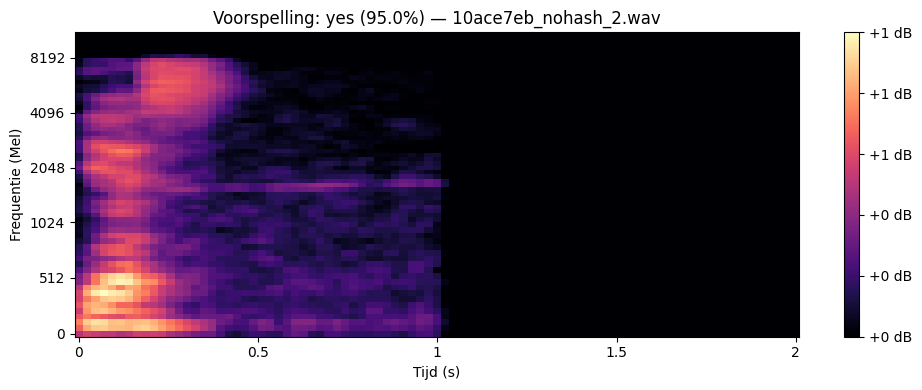

In [10]:
# Kies willekeurig 1 voorbeeldbestand uit elke command-submap
sample_paths = []
for command in commands:
    folder = os.path.join(data_dir, command)
    wavs = [f for f in os.listdir(folder) if f.lower().endswith('.wav')]
    if not wavs:
        print(f"Geen .wav bestanden in: {folder} — overslaan")
        continue
    sample_paths.append(os.path.join(folder, random.choice(wavs)))

# Voorspel en toon spectrogram voor elk gekozen bestand
for sample_path in sample_paths:
    print("Testbestand:", sample_path)
    features = extract_features(sample_path)
    input_data = features[np.newaxis, ..., np.newaxis]

    prediction = model.predict(input_data)
    predicted_label = commands[np.argmax(prediction)]
    confidence = np.max(prediction)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(features, sr=22050, x_axis='time', y_axis='mel', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Voorspelling: {predicted_label} ({confidence*100:.1f}%) — {os.path.basename(sample_path)}")
    plt.xlabel("Tijd (s)")
    plt.ylabel("Frequentie (Mel)")
    plt.tight_layout()
    plt.show()